# Sentiment Data  prediction

The aim of this project is to analyze and predict the sentiment of user comments by examining textual data. The model classifies each comment into sentiment categories such as positive, negative, or neutral based on the content of the text.

This project also aims to identify patterns in text data and understand how different words and expressions influence sentiment classification.

The dataset used in this project contains 49,224 rows and 3 columns (49224, 3), representing a large collection of labeled text data for sentiment analysis.

# Data Dictionary

|Variable|Description
---      | ---    
|id	Unique |identifier for each comment
|Comment	|Text data containing user opinions or feedback
|Sentiment	|Target variable representing sentiment class (e.g., 0 = Negative, 1 = Neutral, 2 = \Positive)

In [34]:
import nltk

# 🔹 One-time downloads
nltk.download('stopwords')
nltk.download('wordnet')


#import all librarys
import pandas as pd
import contractions# this is shoud be up becouse dn't after do not have space near the (do' ') totel 3 letters
import re
from nltk.corpus import stopwords# this word vsuelization and remove stopewordse like am ,for inshit have full pakege like this 
from collections import Counter #afterslipt then cout the  words after remove the stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import wordnet#this give correct format to WordNetLemmatizer
from nltk import pos_tag # this say par of speech run is verb and car is noun
from nltk.stem import WordNetLemmatizer # this is remove runing to run
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import joblib

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMJATH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AMJATH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


DATA COLLECTION

In [35]:
#  Load dataset
df = pd.read_csv("sentiment_data.csv")  





# DATA PREPROCESSING PART 1 = Data Understant + Data cleaning

DATA UNDERSTANTING

In [36]:
#data size
df.shape

(49224, 3)

In [37]:
#columns names 
df.columns

Index(['id', 'Comment', 'Sentiment'], dtype='object')

In [38]:
#data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49224 entries, 0 to 49223
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         49224 non-null  int64 
 1   Comment    49141 non-null  object
 2   Sentiment  49224 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [39]:
#unique values in each column
df.nunique()

id           49224
Comment      45416
Sentiment        3
dtype: int64

In [40]:
#data types of each column
df.dtypes

id            int64
Comment      object
Sentiment     int64
dtype: object

In [41]:

# Check dataset
df.head()

,id,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [42]:
# Check for missing values
df.isnull().sum()

id            0
Comment      83
Sentiment     0
dtype: int64

DATA CLEANING

In [43]:
#drop null veluese
df.dropna(subset=['Comment'], inplace=True)

In [44]:
#drope id columne 
df.drop(columns=['id'], inplace=True)

In [45]:
# Check for empty strings in 'Comment' column
(df['Comment'] == "").sum()

np.int64(0)

In [46]:
#sum duplicated rows
df.duplicated().sum()

np.int64(3654)

In [47]:
#order the duplicat
df[df.duplicated(keep=False)].sort_values(by='Comment')

,Comment,Sentiment
39483,aaaaw windows open,0
47481,aaaaw windows open,0
34477,absolutely,1
19591,absolutely,1
11163,absolutely stunning love voice always somethin...,2
...,...,...
11321,“the best way measure investing success whethe...,2
10253,■ facebook ■ facebook fanpage ■ group ■ instag...,1
10363,■ facebook ■ facebook fanpage ■ group ■ instag...,1
17471,► next days get art pro plus program totally f...,2


In [48]:
# Drop duplicates based on 'Comment' column
df = df.drop_duplicates(subset='Comment')

this sayinhg which is remove which is keep by project wise 
🧠 Real World Advice whiche is remove and which keep wise project
Project	Use
Sentiment analysis	contractions + stopwords + lemmatization
Spam detection	remove links + numbers
Chat data	emoji keep sometimes useful

In [49]:
#this is orginal order by number wise
import re
import contractions

def clean_text(text):
    #1.
    text = str(text).lower()
    #2.fix smart quotes FIRST
    text = text.replace("’", "'")
    #3.remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    #4. expand contractions (BEST STEP) this change text like "don't" to "do not" and "it's" to "it is"
    text = contractions.fix(text)
    #5. remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    #6. remove numbers
    text = re.sub(r'\d+', '', text)
    #7.remove punctuation like !,?,.,, etc but keep spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    #8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    #9. remove repeated characters (like "soooo" to "soo")
    text = re.sub(r'(.)\1+', r'\1\1', text)
    #10. remove non-ASCII characters (like emojis or special symbols)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    #11. remove words with less than 3 characters (like "is", "a", "to", etc)
    text = " ".join([w for w in text.split() if len(w) > 2])

    return text
# 👉 apply to dataframe
df['clean_comment'] = df['Comment'].apply(clean_text)
    




In [50]:
#this is using only pandase for data cleanig
#1.
# df['Comment'] = df['Comment'].str.lower()
# #2.
# # this is shoud be up becouse dnt after do not have space near the (do' ') totel 3 letters
# import contractions
# df['Comment'] = df['Comment'].apply(lambda x: contractions.fix(str(x)))
#   #fix smart quotes FIRST
# df['Comment'] = df['Comment'].replace("’", "'")
 
# # 3. remove HTML t

# df['Comment'] = df['Comment'].str.replace(r'<.*?>', '', regex=True)
# #url remove 
# df['Comment'] = df['Comment'].str.replace(r'http\S+|www\S+', '', regex=True)
# #remove numbers
# df['Comment'] = df['Comment'].str.replace(r'\d+', '', regex=True)
# #remove punctuation like !,?,.,, etc but keep spaces
# df['Comment'] = df['Comment'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
# #remove extra spaces
# df['Comment'] = df['Comment'].str.replace(r'\s+', ' ', regex=True).str.strip()
# #7. remove repeated characters (like "soooo" to "soo")
# df['Comment'] = df['Comment'].astype(str).str.replace(r'(.)\1+', r'\1\1', regex=True)
# # 8. remove non-ASCII characters (like emojis or special symbols)
# df['Comment'] = df['Comment'].str.replace(r'[^\x00-\x7F]+', '', regex=True)
# #is have " ".join this have empty string  not have this " ".join empty no 
# df['Comment'] = df['Comment'].apply(lambda x: " ".join([w for w in str(x).split() if len(w) > 2])) #this 2 is removw
#letter 2 and under 2 letters  



In [51]:
#drop the old comment column
df.drop(columns=['Comment'], inplace=True)

In [52]:
#sum of empty
(df['clean_comment'] == "").sum()

np.int64(248)

In [53]:
# Check for empty strings in 'clean_comment' column after cleaning emoji  ! like this some times get empty rowes

df[df['clean_comment'] == ""]

,Sentiment,clean_comment
35,1,
652,1,
658,1,
660,1,
663,1,
...,...,...
34777,1,
37262,1,
40951,0,
46829,1,


In [54]:
#check for empty and null values in 'clean_comment' column
empty_count = (df['clean_comment'] == "").sum()
null_count = df['clean_comment'].isnull().sum()


print("Empty:", empty_count)
print("Null:", null_count)

Empty: 248
Null: 0


In [55]:
#dropthe empty and null values in 'clean_comment' column
df = df[df['clean_comment'].notnull()]
df = df[df['clean_comment'].str.strip() != ""]



In [56]:
df.head(50)

,Sentiment,clean_comment
0,1,let forget apple pay required brand new iphone...
1,0,retailers not even contactless credit card mac...
2,2,forever acknowledge channel help lessons ideas...
3,0,whenever place does not take apple pay does no...
4,2,apple pay convenient secure easy use used kore...
5,1,have hounding bank adopt apple pay understand ...
6,2,got apple pay south africa widely accepted
7,1,need apple pay physical credit card
8,2,united states abundance retailers accept apple...
9,1,cambodia universal code system scan send money...


# EXPLOR DATA ANALYSIS

In [57]:
#descriptive  dataset
df.describe()

,Sentiment
count,45168.000000
mean,1.205433
std,0.785899
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2.000000


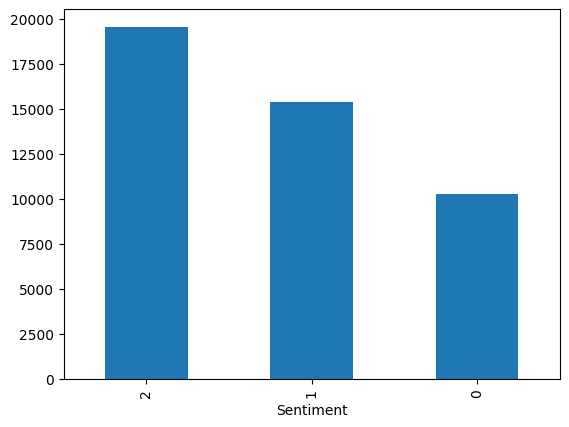

In [58]:
# Distribution of sentiments
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.show()

This bar chart represents the distribution of sentiments in the dataset. The dataset contains three classes: Positive (2), Neutral (1), and Negative (0). From the visualization, it is clear that the Positive class has the highest number of samples, followed by Neutral, while Negative has the lowest count.

This indicates that the dataset is slightly imbalanced, with more positive reviews compared to negative and neutral reviews. Such an imbalance can affect the performance of the machine learning model, as it may become biased toward predicting the positive class more often.

To improve model performance, techniques such as class balancing, oversampling, or using class weights can be applied. Overall, this distribution gives a clear understanding of how sentiment data is spread across different categories in the dataset.

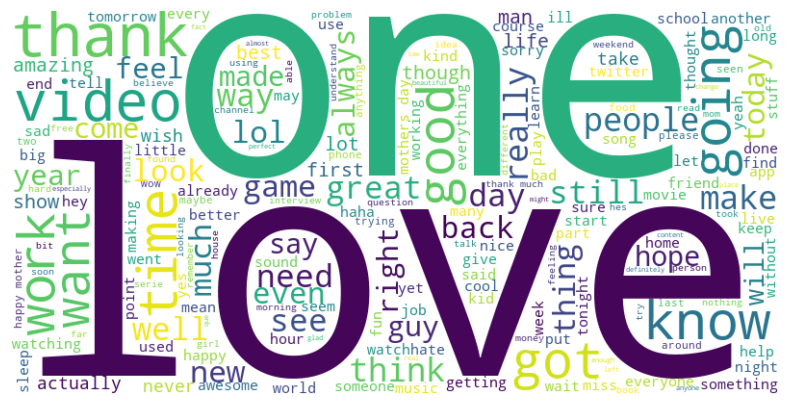

In [59]:
# Word Cloud of comments this is best for text data visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# join all comments into one big text
text = " ".join(df['clean_comment'].dropna())

# create word cloud
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

# display
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

The word cloud visualization represents the most frequently occurring words in the dataset. Larger words such as “love,” “good,” “now,” and “going” indicate that these terms appear more often in the text data. Words like “love” and “good” suggest a strong presence of positive sentiment, while other commonly used words such as “now,” “still,” and “today” reflect general conversational language. The presence of meaningful words alongside common terms indicates that the preprocessing steps, such as stopword removal, have been applied effectively. Overall, the word cloud helps in quickly identifying key patterns and dominant terms in the dataset, providing insights into the nature and tone of the text data.

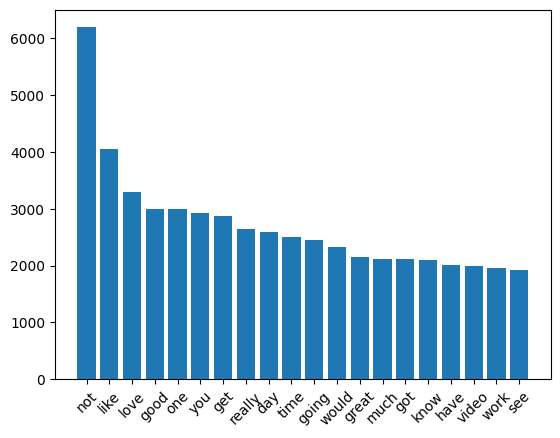

In [60]:
from collections import Counter
import matplotlib.pyplot as plt

words = " ".join(df['clean_comment']).split()
common = Counter(words).most_common(20)

w, c = zip(*common)

plt.bar(w, c)
plt.xticks(rotation=45)
plt.show()

this bar chart word frequency analysis shows the most commonly occurring words in the dataset after preprocessing. The word “not” appears most frequently with a count of 6,197, indicating the importance of negation in the text, which can strongly influence sentiment. Other high-frequency words such as “like,” “love,” “good,” and “great” suggest a significant presence of positive sentiment in the dataset. At the same time, commonly used words like “one,” “get,” “really,” “time,” and “going” reflect general conversational language patterns. The presence of words like “cannot” and “not” also highlights that negative expressions are still important features for classification. Overall, this distribution indicates a mix of sentiment-bearing words and common contextual words, which helps the model learn both emotional tone and general language structure effectively

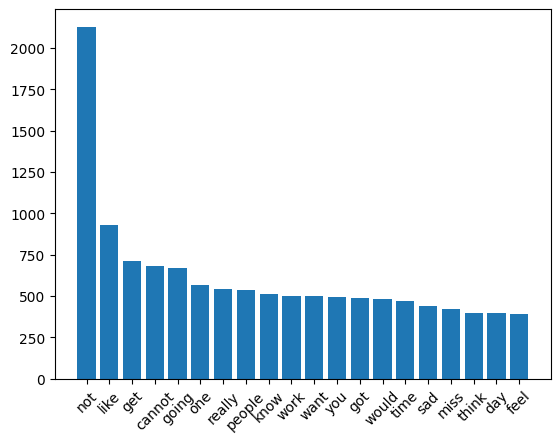

In [61]:
from collections import Counter
import matplotlib.pyplot as plt

negative = df[df['Sentiment'] == 0]

words = " ".join(negative['clean_comment']).split()
common = Counter(words).most_common(20)

w, c = zip(*common)

plt.bar(w, c)
plt.xticks(rotation=45)
plt.show()

In this bar chart words like “not,” “sad,” “miss,” “bad,” “sorry,” “feel,” “still,” and “time” appear very frequently, and they are strongly linked with negative sentiment in many sentences. The word “not” is the most common because it is often used to cancel or reverse meaning (for example: “not good,” “not happy”). Words like “sad,” “bad,” “miss,” and “sorry” clearly express emotional negativity, showing feelings of disappointment, loss, or regret. Other words such as “want,” “would,” “think,” “still,” “back,” and “could” are not always negative by themselves, but in real text data they often appear in negative or emotional contexts, which is why they are frequently captured in the negative word list. Overall, these words help your model understand negative emotions, but many of them are context-dependent, meaning their sentiment depends on the full sentence rather than the single word alone.

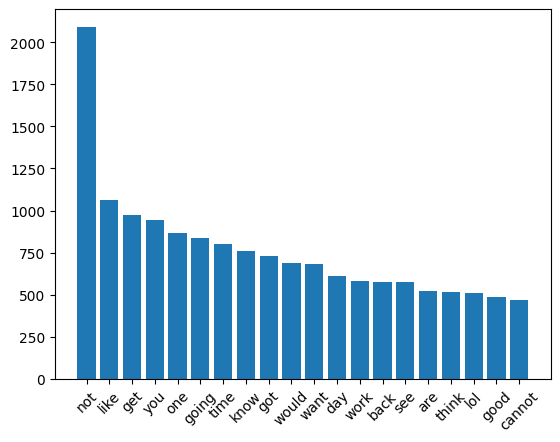

In [62]:
from collections import Counter
import matplotlib.pyplot as plt

neutral = df[df['Sentiment'] == 1]

words = " ".join(neutral['clean_comment']).split()
common = Counter(words).most_common(20)

w, c = zip(*common)

plt.bar(w, c)
plt.xticks(rotation=45)
plt.show()

In this bar chart the most frequent neutral words such as “going,” “would,” “want,” “day,” “back,” “see,” “think,” “today,” “still,” “make,” “could,” and “home” are mainly used to build sentences rather than express strong emotions. These words are very common in everyday communication and often appear in both positive and negative sentences. For example, words like “think,” “see,” and “make” are action words that depend fully on context, while words like “day,” “today,” and “home” describe time or place rather than feelings. Even words like “good” and “well” can be neutral in some cases because they do not always strongly affect sentiment without surrounding context. Overall, these neutral words form the “base structure” of sentences, helping your model understand meaning, but they usually do not directly indicate whether the text is positive or negative

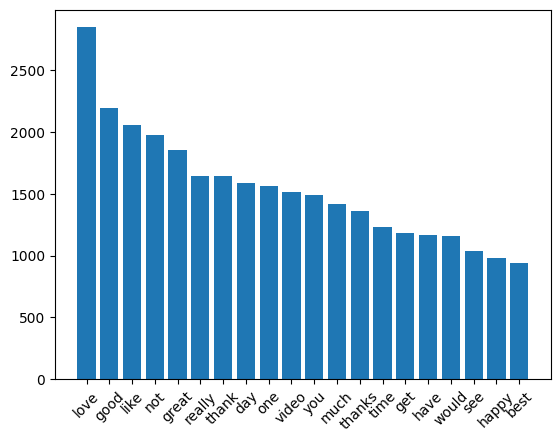

In [63]:
from collections import Counter
import matplotlib.pyplot as plt

positive = df[df['Sentiment'] == 2]

words = " ".join(positive['clean_comment']).split()
common = Counter(words).most_common(20)

w, c = zip(*common)

plt.bar(w, c)
plt.xticks(rotation=45)
plt.show()

in this bar chart the most frequent positive words such as “love,” “good,” “great,” “thank,” “thanks,” “happy,” “best,” and “amazing” clearly express positive emotions like happiness, satisfaction, and appreciation. Words like “love” (2846 occurrences) and “good” (2190 occurrences) show strong positive sentiment and are often used to describe enjoyable experiences or approval. Expressions such as “thank” and “thanks” indicate gratitude, while words like “happy,” “best,” and “amazing” reflect strong emotional positivity. Some common words like “day,” “going,” “would,” and “see” appear frequently but are context-dependent—they become positive when used in positive sentences. Overall, these words help your model identify happiness, appreciation, and positive opinions in text data, making them very important for accurate sentiment classification.

In [64]:
# this word vsuelization
from nltk.corpus import stopwords
from collections import Counter
#1.
negative_stop_words = set(stopwords.words('english'))
negative_stop_words.discard('not')

#2.
negative = df[df['Sentiment'] == 0] #this is  also data frame 
#3. this menuel 
#custom_stopwords= {'even','mother','twitter','well','day','today','yeah','like', 'get', 'come', 'apple', 'iphone','one','really','go','work','people','know','time','got','good','everyone','support'}
words = " ".join(negative['clean_comment'].dropna()).lower().split()#("")this non spece (" ") this is spece #"".join(["good","bad"]) → "goodbad"
#4. this autometic
word_counts = Counter(words)

#5. remove too frequent and too rare words
auto_stopwords = {
    w for w, c in word_counts.items()
    if c > 500 or c < 2   # too frequent OR too rare
}

#6. combine stopwords
negative_all_stopwords = negative_stop_words.union(auto_stopwords)

#7. filter words

filtered_words = [
        w for w in words
        if w not in negative_all_stopwords or w in ['not', 'no', 'never']
    ]


# ✅ THIS LINE IMPORTANT
Counter(filtered_words).most_common(20)



[('not', 2129),
 ('want', 497),
 ('got', 486),
 ('would', 480),
 ('time', 470),
 ('sad', 439),
 ('miss', 422),
 ('think', 399),
 ('day', 398),
 ('feel', 392),
 ('still', 388),
 ('bad', 386),
 ('even', 382),
 ('much', 380),
 ('sorry', 356),
 ('back', 354),
 ('today', 342),
 ('good', 326),
 ('see', 307),
 ('could', 307)]

In [65]:
# this is counting most common word in neutral comments 
from nltk.corpus import stopwords
from collections import Counter

neutral_stop_words = set(stopwords.words('english'))

extra_words = {
    'im','dont','cant','like','get','one','really','go',
    'work','people','know','time','got','de'
}

neutral_all_stopwords = neutral_stop_words.union(extra_words)

neutral = df[df['Sentiment'] == 1]

words = " ".join(neutral['clean_comment'].dropna()).lower().split()

filtered_words = [
    word for word in words 
    if word not in neutral_all_stopwords
    and len(word) > 2
]

Counter(filtered_words).most_common(20)

[('going', 837),
 ('would', 688),
 ('want', 683),
 ('day', 613),
 ('back', 575),
 ('see', 575),
 ('think', 516),
 ('lol', 510),
 ('good', 486),
 ('cannot', 470),
 ('today', 469),
 ('need', 464),
 ('new', 463),
 ('still', 452),
 ('make', 440),
 ('que', 424),
 ('well', 418),
 ('could', 394),
 ('way', 380),
 ('home', 366)]

In [66]:
# Word frequency in positive comments somtime is have any null value use dropna  like this 
# words = " ".join(positive['Comment'].dropna()).split()
# this is counting most common word in positve comments 
from nltk.corpus import stopwords
from collections import Counter

positive_stop_words = set(stopwords.words('english'))

extra_words = {
    'im','dont','cant','like','get','one','really','go',
    'work','people','know','time','got','de','video'
}

positive_all_stopwords = positive_stop_words.union(extra_words)

positive = df[df['Sentiment'] == 2]

words = " ".join(positive['clean_comment'].dropna()).lower().split()

filtered_words = [
    word for word in words 
    if word not in positive_all_stopwords
    and len(word) > 2
]

Counter(filtered_words).most_common(20)


[('love', 2846),
 ('good', 2190),
 ('great', 1853),
 ('thank', 1646),
 ('day', 1584),
 ('much', 1418),
 ('thanks', 1360),
 ('would', 1160),
 ('see', 1035),
 ('happy', 980),
 ('best', 942),
 ('going', 941),
 ('videos', 917),
 ('well', 875),
 ('amazing', 853),
 ('always', 801),
 ('make', 783),
 ('way', 761),
 ('hope', 755),
 ('new', 745)]

# DATA PREPROCCSING PART 2

In [67]:
# this word vsuelization
from nltk.corpus import stopwords 
from collections import Counter 
#1. 
stop_words = set(stopwords.words('english'))
stop_words.discard('not') 
#2. #3. this menuel #custom_stopwords= {'even','mother','twitter','well','day','today','yeah','like', 'get', 'come', 'apple', 'iphone','one','really','go','work','people','know','time','got','good','everyone','support'}
words = " ".join(df['clean_comment'].dropna()).lower().split()#("")this non spece (" ") this is spece #"".join(["good","bad"]) → "goodbad" 
#4. this autometic
word_counts = Counter(words) 
important_words = {"not", "good", "bad", "love", "hate"} 
#5. remove too frequent and too rare words
auto_stopwords = { w for w, c in word_counts.items() if c < 3 and w not in important_words}
 # too frequent OR too rare this is rediuse the ovrefit to good fit }
 #  #this is main in this #6. combine stopwords
all_stopwords = stop_words.union(auto_stopwords) # combine all stopwords 
#7. filter words 
filtered_words = [ w for w in words if w not in all_stopwords or w in ['not', 'no', 'never'] ] # ✅ THIS LINE IMPORTANT 
Counter(filtered_words).most_common(20)


[('not', 6197),
 ('like', 4051),
 ('love', 3301),
 ('good', 3002),
 ('one', 2995),
 ('get', 2865),
 ('really', 2643),
 ('day', 2595),
 ('time', 2502),
 ('going', 2446),
 ('would', 2328),
 ('great', 2154),
 ('much', 2118),
 ('got', 2109),
 ('know', 2103),
 ('video', 1987),
 ('work', 1951),
 ('see', 1917),
 ('want', 1883),
 ('cannot', 1825)]

In [68]:
#this after visulization ender in data frame we have to remove stop words and this is important step for word visulization in rowse
#uplod this to data fram afer clean stopewords
df['final_clean_comment'] = df['clean_comment'].apply(
    lambda x: " ".join([
        w for w in str(x).split()
        if w not in all_stopwords or w in ['not', 'no', 'never']
    ])
)

In [69]:
df.head()

,Sentiment,clean_comment,final_clean_comment
0,1,let forget apple pay required brand new iphone...,let forget apple pay required brand new iphone...
1,0,retailers not even contactless credit card mac...,retailers not even credit card machines like s...
2,2,forever acknowledge channel help lessons ideas...,forever acknowledge channel help lessons ideas...
3,0,whenever place does not take apple pay does no...,whenever place not take apple pay not happen o...
4,2,apple pay convenient secure easy use used kore...,apple pay convenient secure easy use used kore...


In [70]:
#drop the clean coment column
df.drop(columns=['clean_comment'], inplace=True)

In [71]:
#order of columns
df = df[['final_clean_comment', 'Sentiment']]

In [72]:
df.head()

,final_clean_comment,Sentiment
0,let forget apple pay required brand new iphone...,1
1,retailers not even credit card machines like s...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever place not take apple pay not happen o...,0
4,apple pay convenient secure easy use used kore...,2


In [73]:
#This function helps lemmatization understand grammar (verb/noun/adjective)
#  so it can reduce words correctly.
from nltk.corpus import wordnet
from nltk import pos_tag

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [74]:
#it can reduce words correctly like runnig to run .
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def after_cleaning_text(text):
    words = text.split()
    tagged_words = pos_tag(words)

    cleaned_words = []

    for w, pos in tagged_words:
        if w in all_stopwords:#add my auto remove after visulization stop words
            continue

        wn_pos = get_wordnet_pos(pos)

        lemma = lemmatizer.lemmatize(w, wn_pos)

        # 🔥 fix for verbs (important)
        if wn_pos == 'v' and lemma == w:
            lemma = lemmatizer.lemmatize(w, 'v')

        cleaned_words.append(lemma)

    return " ".join(cleaned_words)

In [75]:

#clean comments
df['after_final_clean_comment'] = df['final_clean_comment'].apply(after_cleaning_text)


In [76]:
df.head(50)

,final_clean_comment,Sentiment,after_final_clean_comment
0,let forget apple pay required brand new iphone...,1,let forget apple pay require brand new iphone ...
1,retailers not even credit card machines like s...,0,retailer not even credit card machine like sup...
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lesson ideas ...
3,whenever place not take apple pay not happen o...,0,whenever place not take apple pay not happen o...
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...
5,bank adopt apple pay understand not want extra...,1,bank adopt apple pay understand not want extra...
6,got apple pay south africa widely accepted,2,get apple pay south africa widely accept
7,need apple pay physical credit card,1,need apple pay physical credit card
8,united states abundance retailers accept apple...,2,united state abundance retailer accept apple p...
9,universal code system scan send money back for...,1,universal code system scan send money back for...


In [77]:
#dropthe unwanted column 
df.drop(columns=['final_clean_comment'], inplace=True)

In [78]:
#order of columns
df = df[['after_final_clean_comment', 'Sentiment']]

In [79]:
df.head(50)

,after_final_clean_comment,Sentiment
0,let forget apple pay require brand new iphone ...,1
1,retailer not even credit card machine like sup...,0
2,forever acknowledge channel help lesson ideas ...,2
3,whenever place not take apple pay not happen o...,0
4,apple pay convenient secure easy use used kore...,2
5,bank adopt apple pay understand not want extra...,1
6,get apple pay south africa widely accept,2
7,need apple pay physical credit card,1
8,united state abundance retailer accept apple p...,2
9,universal code system scan send money back for...,1


In [80]:
#check the data after limmtizer is have a empty
(df['after_final_clean_comment'] == "").sum()

np.int64(250)

In [81]:
##check the data after limmtizer is have empty in in data frame
df[df['after_final_clean_comment'] == ""]

,after_final_clean_comment,Sentiment
654,,1
655,,1
664,,1
665,,1
666,,1
...,...,...
46724,,1
47548,,1
48139,,2
48893,,1


In [82]:


#check for empty and null values in 'clean_comment' column
empty_count = (df['after_final_clean_comment'] == "").sum()
null_count = df['after_final_clean_comment'].isnull().sum()


print("Empty:", empty_count)
print("Null:", null_count)

Empty: 250
Null: 0


In [83]:
#dropthe empty and null values in 'clean_comment' column
df = df[df['after_final_clean_comment'].notnull()]
df = df[df['after_final_clean_comment'].str.strip() != ""]

In [84]:
df.head(1000)

,after_final_clean_comment,Sentiment
0,let forget apple pay require brand new iphone ...,1
1,retailer not even credit card machine like sup...,0
2,forever acknowledge channel help lesson ideas ...,2
3,whenever place not take apple pay not happen o...,0
4,apple pay convenient secure easy use used kore...,2
...,...,...
1087,subscribe,2
1089,dream gaming monitor,1
1090,wow impressed think set new bar spec,2
1091,monitor look really clean almost bezel like ge...,2


# MODEL CREAT 
= TRAIN and test +data encoding + model bulting + MODEL EVALUTION

In [85]:
#first split test and train data befor  tokenization  encoding
X = df['after_final_clean_comment']
Y = df['Sentiment']

TRAIN AND TEST 

In [86]:
#split data like test and train
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=df['Sentiment'])
    

data encoding 

In [87]:
#this partof secter
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
       min_df=20,#20 times  is documents (rows / comments)1 row = 1 document this importent to overfit rediuse to goodfit
                #for exaple even (25) that  not remove even (15) this is remove 
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)


MODEL BULDING

In [88]:
# 9️⃣ Model training
from sklearn.svm import LinearSVC
model = LinearSVC(C=0.05)# this is also ridiuse the overfit to goodfit 

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.05
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo ran

MODEL EVALUETION

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Predictions
# =========================
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)

# =========================
# Metrics
# =========================
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='macro')  # use 'macro' if multi-class 0,1,2
test_precision  = precision_score(y_test, y_test_pred, average='macro')   # use 'binary' if 0,1 only

train_recall = recall_score(y_train, y_train_pred, average='macro')
test_recall  = recall_score(y_test, y_test_pred, average='macro')

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1  = f1_score(y_test, y_test_pred, average='macro')

# =========================
# Print Results
# =========================
print("🔹 TRAIN")
print("Accuracy :", train_accuracy)
print("Precision:", train_precision)
print("Recall   :", train_recall)
print("F1-score :", train_f1)
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

print("\n🔹 TEST")
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1-score :", test_f1)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# =========================
# Fit Check Logic
# =========================
print("\n🔍 MODEL FIT CHECK")

if train_accuracy > test_accuracy + 0.15:
    print("❌ Overfitting (Train accuracy much higher than Test accuracy)")

elif test_accuracy > train_accuracy + 0.15:
    print("⚠️ Unusual case (Test accuracy higher than Train, check data)")

elif train_accuracy < 0.6 and test_accuracy < 0.6:
    print("❌ Underfitting (Both accuracies low)")

else:
    print("✅ Good Fit")

🔹 TRAIN
Accuracy : 0.7394946290421328
Precision: 0.7414016232181021
Recall   : 0.7110110980855282
F1-score : 0.7197940269402753
Confusion Matrix:
 [[ 4602  2600   988]
 [ 1025  8920  2198]
 [  346  2204 13051]]

🔹 TEST
Accuracy : 0.711487088156723
Precision: 0.7081602163010468
Recall   : 0.6802809759119203
F1-score : 0.6882591060412401
Confusion Matrix:
 [[1077  710  261]
 [ 325 2085  626]
 [  89  581 3230]]

🔍 MODEL FIT CHECK
✅ Good Fit


auto_stopwords =
    w for w, c in word_counts.items()
    if c < 3 and w not in important_words and
     min_df=20, this chanhing impact to overfittiting
    model = LinearSVC(C=0.05)# this is also ridiuse the overfit to goodfit 

EXAMPLE PRIDICTION

In [90]:
samples = [
    "bye great meeting",
    "alright joking said wine fool maybe dont like drinking",
    "imaginations thought could run wild animalbut damn hyena would dead secs",
    "thanks teflon liver scottish raised whisky",]
#1
def preprocess(text):
    text = clean_text(text)   # நீங்க already use பண்ண function
    return text

# 2. stopwords fix (BEST PRACTICE)
negative_stopwords = set(all_stopwords)
negative_stopwords.discard('not')
negative_stopwords.discard('no')
negative_stopwords.discard('never')

def stopword_preprocess(text):
    words = str(text).split()
    
    filtered_words = [
        w for w in words
        if w not in negative_stopwords
    ]
    
    return " ".join(filtered_words)
#3.
def lemmatizer_preprocess(text):
    text = after_cleaning_text(text)   # get_wordnet_pos(tag): this is have inshit 
    return text


# 1,2,3. apply preprocessing
samples_clean = [preprocess(s) for s in samples]
stopwordes_samples_clean = [stopword_preprocess(s) for s in samples_clean]
lemmatizer_cleaning_text = [lemmatizer_preprocess(s) for s in stopwordes_samples_clean]

# 4transform
X_sample = tfidf.transform(lemmatizer_cleaning_text)

# predict
preds = model.predict(X_sample)

for text, pred in zip(samples, preds):
    print(text, "->", pred)

bye great meeting -> 2
alright joking said wine fool maybe dont like drinking -> 1
imaginations thought could run wild animalbut damn hyena would dead secs -> 0
thanks teflon liver scottish raised whisky -> 2


save the model

In [91]:
import joblib

#joblib.dump(clean_text,"clean_text.pkl") not do for function dfe:
joblib.dump(all_stopwords, "stopwords.pkl")# this use in clean lemmitiy py fill
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
#joblib.dump(lemmatizer_preprocess,"lemmatizer_preprocess.pkl")


['tfidf_vectorizer.pkl']